In [124]:
import os
import sys
# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join('..', '..')) 
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis" 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from ..data.model_data import return_data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
from ..data.connection import return_topic_labels

In [125]:
data = return_data(market_data="all").set_index("date")
sentiment_columns = [
    'finbert_IS_mean', 'roberta_IS_mean',
    'finbert_QA_mean', 'roberta_QA_mean',
    'finbert_IS_max', 'roberta_IS_max',
]
data["MRO_diff"] = data["MRO announced"] - data["MRO"]

In [156]:
pre_zlb = data.loc[:'2014-01-01'].dropna(subset=sentiment_columns + ['MRO_diff'])
X = pre_zlb[sentiment_columns]
y = (pre_zlb['MRO_diff'] > 0).astype(int)  # 1 = rate hike, 0 = cut/hold

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [157]:
y_prob = model.predict_proba(X_scaled)[:, 1]
auc = roc_auc_score(y, y_prob)
print(f"AUC (pre-ZLB): {auc:.3f}")
print(classification_report(y, model.predict(X_scaled)))

AUC (pre-ZLB): 0.920
              precision    recall  f1-score   support

           0       0.99      0.80      0.89       158
           1       0.31      0.93      0.47        15

    accuracy                           0.82       173
   macro avg       0.65      0.87      0.68       173
weighted avg       0.93      0.82      0.85       173



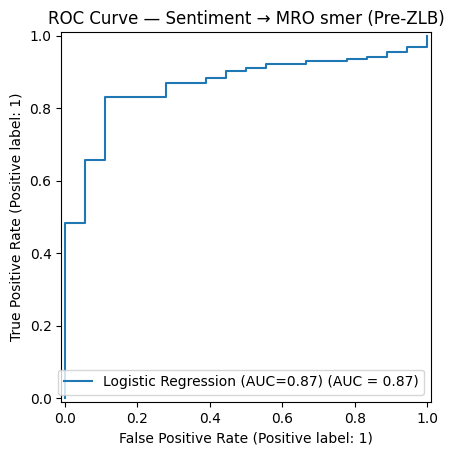

In [151]:
RocCurveDisplay.from_predictions(y, y_prob, name=f"Logistic Regression (AUC={auc:.2f})")
plt.title("ROC Curve — Sentiment → MRO smer (Pre-ZLB)")
plt.show()

# --- ZLB: predict sign of pc1 ---
zlb = data.loc['2014-01-01':'2021-12-31'].dropna(subset=sentiment_columns + ['pc1'])
X2 = zlb[sentiment_columns]
y2 = (zlb['pc1'] > 0).astype(int)  # 1 = hawkish surprise, 0 = dovish

X2_scaled = scaler.fit_transform(X2)
model2 = LogisticRegression(max_iter=1000)
model2.fit(X2_scaled, y2)
pass

AUC (ZLB, pc1): 0.605


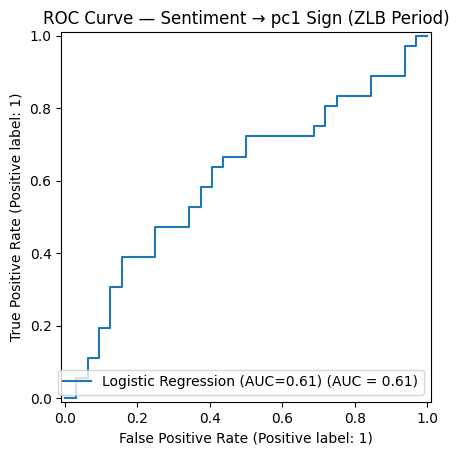

In [129]:
y_prob2 = model2.predict_proba(X2_scaled)[:, 1]
auc2 = roc_auc_score(y2, y_prob2)
print(f"AUC (ZLB, pc1): {auc2:.3f}")

RocCurveDisplay.from_predictions(y2, y_prob2, name=f"Logistic Regression (AUC={auc2:.2f})")
plt.title("ROC Curve — Sentiment → pc1 Sign (ZLB Period)")
plt.show()

In [130]:
print(data[['MP_pm', 'CBI_pm', 'MP_median', 'CBI_median']].describe())
print("\nMP_pm sign balance:")
print((data['MP_pm'] > 0).value_counts())
print("\nCBI_pm sign balance:")
print((data['CBI_pm'] > 0).value_counts())

            MP_pm      CBI_pm   MP_median  CBI_median
count  272.000000  272.000000  272.000000  272.000000
mean     0.002865    0.000860    0.004609   -0.000884
std      0.036390    0.028057    0.034911    0.030046
min     -0.233329   -0.163802   -0.142502   -0.120139
25%     -0.000000    0.000000   -0.010831   -0.012462
50%      0.000000    0.000000    0.001475   -0.001251
75%      0.002197    0.000000    0.017885    0.011543
max      0.203563    0.200709    0.189967    0.137062

MP_pm sign balance:
MP_pm
False    194
True      78
Name: count, dtype: int64

CBI_pm sign balance:
CBI_pm
False    213
True      59
Name: count, dtype: int64


In [131]:
# Drop the zeros — only keep meetings where something actually surprised markets
mp_nonzero = data[data['MP_pm'] != 0].dropna(subset=sentiment_columns + ['MP_pm'])
print("MP_pm nonzero balance:")
print((mp_nonzero['MP_pm'] > 0).value_counts())

cbi_nonzero = data[data['CBI_pm'] != 0].dropna(subset=sentiment_columns + ['CBI_pm'])
print("\nCBI_pm nonzero balance:")
print((cbi_nonzero['CBI_pm'] > 0).value_counts())

mro_diff_nonzero = data[data['MRO_diff'] != 0].dropna(subset=sentiment_columns + ['MRO_diff'])
print("\nMRO_diff nonzero balance:")
print((mro_diff_nonzero['MRO_diff'] > 0).value_counts())

MP_pm nonzero balance:
MP_pm
True     78
False    67
Name: count, dtype: int64

CBI_pm nonzero balance:
CBI_pm
False    66
True     59
Name: count, dtype: int64

MRO_diff nonzero balance:
MRO_diff
False    29
True     25
Name: count, dtype: int64



--- MP_pm ---
In-sample AUC:       0.616
Cross-validated AUC: 0.436
              precision    recall  f1-score   support

           0       0.62      0.42      0.50        67
           1       0.61      0.78      0.69        78

    accuracy                           0.61       145
   macro avg       0.62      0.60      0.59       145
weighted avg       0.62      0.61      0.60       145


--- CBI_pm ---
In-sample AUC:       0.612
Cross-validated AUC: 0.283
              precision    recall  f1-score   support

           0       0.59      0.74      0.66        66
           1       0.60      0.42      0.50        59

    accuracy                           0.59       125
   macro avg       0.59      0.58      0.58       125
weighted avg       0.59      0.59      0.58       125



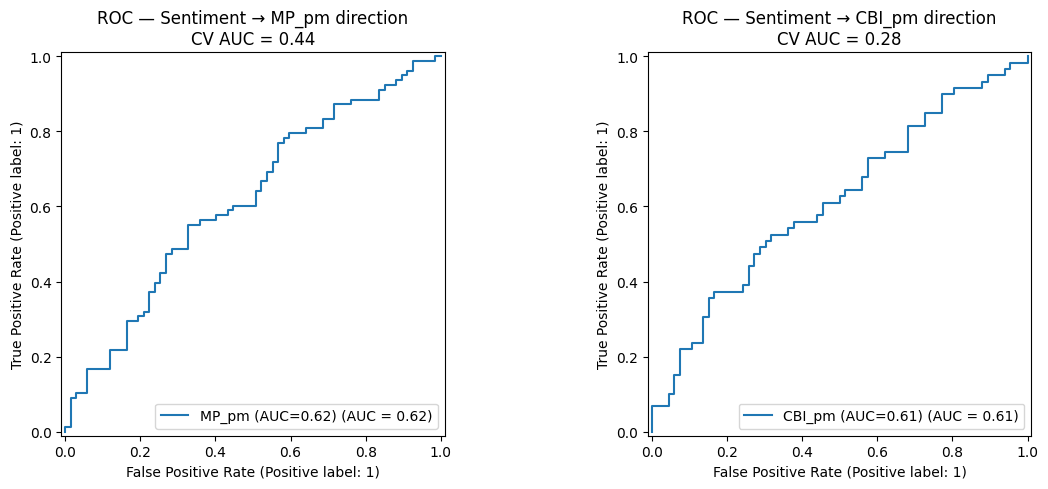

In [ ]:
sentiment_columns = [
    'finbert_IS_mean', 'roberta_IS_mean',
    'finbert_QA_mean', 'roberta_QA_mean',
    'finbert_IS_max', 'roberta_IS_max',
]

targets = {
    'MP_pm':  data[data['MP_pm']  != 0].dropna(subset=sentiment_columns + ['MP_pm']),
    'CBI_pm': data[data['CBI_pm'] != 0].dropna(subset=sentiment_columns + ['CBI_pm']),
}

scaler = StandardScaler()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, subset) in zip(axes, targets.items()):
    X = scaler.fit_transform(subset[sentiment_columns])
    y = (subset[name] > 0).astype(int)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    
    y_prob = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_prob)
    
    # Cross-validated AUC (more honest for thesis)
    cv_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
    
    print(f"\n--- {name} ---")
    print(f"In-sample AUC:       {auc:.3f}")
    print(f"Cross-validated AUC: {cv_auc:.3f}")
    print(classification_report(y, model.predict(X)))
    
    RocCurveDisplay.from_predictions(y, y_prob, ax=ax, name=f"{name} (AUC={auc:.2f})")
    ax.set_title(f"ROC — Sentiment → {name} direction\nCV AUC = {cv_auc:.2f}")

plt.tight_layout()
plt.show()

In [133]:
data_labeled = return_data(with_label=True, market_data="all").set_index("date")
data_labeled["MRO_diff"] = data_labeled["MRO announced"] - data_labeled["MRO"]
finbert_cols = [c for c in data_labeled.columns if c.startswith('finbert')]
roberta_cols = [c for c in data_labeled.columns if c.startswith('roberta')]

mp_data = data_labeled[data_labeled['MP_pm'] != 0].dropna(subset=finbert_cols + roberta_cols + ['MP_pm'])
y = (mp_data['MP_pm'] > 0).astype(int)

scaler = StandardScaler()

for name, cols in [('FinBERT', finbert_cols), ('RoBERTa', roberta_cols)]:
    X = scaler.fit_transform(mp_data[cols])
    model = LogisticRegression(max_iter=1000)
    cv_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
    print(f"{name} CV AUC (MP_pm): {cv_auc:.3f}")

FinBERT CV AUC (MP_pm): 0.445
RoBERTa CV AUC (MP_pm): 0.524


In [134]:
data.columns

Index(['pc1', 'STOXX50_x', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'OIS_1M', 'OIS_3M', 'OIS_6M', 'OIS_1Y', 'DE2Y', 'DE10Y', 'IT2Y', 'FR2Y',
       'ES2Y', 'ES10Y', 'FR10Y', 'IT10Y', 'STOXX50_y', 'MRO', 'DF announced',
       'DF effective', 'Wu-Xia shadow rate', 'MRO announced', 'MRO effective',
       'finbert_IS_max', 'finbert_QA_max', 'roberta_IS_max', 'roberta_QA_max',
       'finbert_IS_mean', 'finbert_QA_mean', 'roberta_IS_mean',
       'roberta_QA_mean', 'finbert_IS_min', 'finbert_QA_min', 'roberta_IS_min',
       'roberta_QA_min', 'finbert_IS_std', 'finbert_QA_std', 'roberta_IS_std',
       'roberta_QA_std', 'MRO_diff'],
      dtype='str')

In [135]:
mp_topic_cols = [c for c in data_labeled.columns if '_MP_' in c and 'finbert' in c]
print(mp_topic_cols)

['finbert_IS_MP_max', 'finbert_QA_MP_max', 'finbert_IS_MP_mean', 'finbert_QA_MP_mean', 'finbert_IS_MP_min', 'finbert_QA_MP_min', 'finbert_IS_MP_std', 'finbert_QA_MP_std']


In [136]:
mp_data = data_labeled[data_labeled['MP_pm'] != 0].dropna(subset=mp_topic_cols + ['MP_pm'])
y = (mp_data['MP_pm'] > 0).astype(int)

X = scaler.fit_transform(mp_data[mp_topic_cols])
model = LogisticRegression(max_iter=1000)
cv_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
print(f"FinBERT MP-topic only CV AUC: {cv_auc:.3f}")
print(f"n samples: {len(mp_data)}")

FinBERT MP-topic only CV AUC: 0.497
n samples: 145


In [137]:
topic_sentiment_cols = [c for c in data_labeled.columns 
                        if any(t in c for t in ['_EP_', '_FS_', '_MP_', '_OI_'])
                        and 'mean' in c]

print(data_labeled[topic_sentiment_cols + ['MRO_diff', 'Wu-Xia shadow rate']]
      .corr()[['MRO_diff', 'Wu-Xia shadow rate']]
      .loc[topic_sentiment_cols]
      .to_string())

                    MRO_diff  Wu-Xia shadow rate
finbert_IS_EP_mean  0.095237            0.021111
finbert_IS_FS_mean  0.045096           -0.319792
finbert_IS_MP_mean  0.167516           -0.431772
finbert_IS_OI_mean  0.027910           -0.239537
finbert_QA_EP_mean  0.046861            0.018426
finbert_QA_FS_mean  0.006461           -0.062455
finbert_QA_MP_mean  0.193588           -0.002815
finbert_QA_OI_mean -0.007548           -0.038514
roberta_IS_EP_mean  0.193338            0.119940
roberta_IS_FS_mean -0.037905           -0.516262
roberta_IS_MP_mean -0.120532           -0.565168
roberta_IS_OI_mean  0.149893           -0.347130
roberta_QA_EP_mean  0.061008            0.042478
roberta_QA_FS_mean -0.080181            0.008377
roberta_QA_MP_mean -0.040487           -0.012965
roberta_QA_OI_mean -0.011496            0.176660


In [138]:
return_topic_labels(0)

{'MONETARY_POLICY_AND_INFLATION': ('inflation, price stability, interest rate decisions, monetary policy stance, financing conditions, bank lending, and market interest rates',
  1),
 'ECONOMIC_PERFORMANCE': ('economic growth, GDP outlook, unemployment, labor market developments, macroeconomic risks, demand, consumption, and investment',
  2),
 'FISCAL_AND_STRUCTURAL': ('government budgets, national debt, public spending, and structural reforms',
  3),
 'OTHER_IRRELEVANT': ('general greetings, purely political questions, unrelated remarks, climate change, or personal comments (excluding macroeconomic impacts)',
  4)}

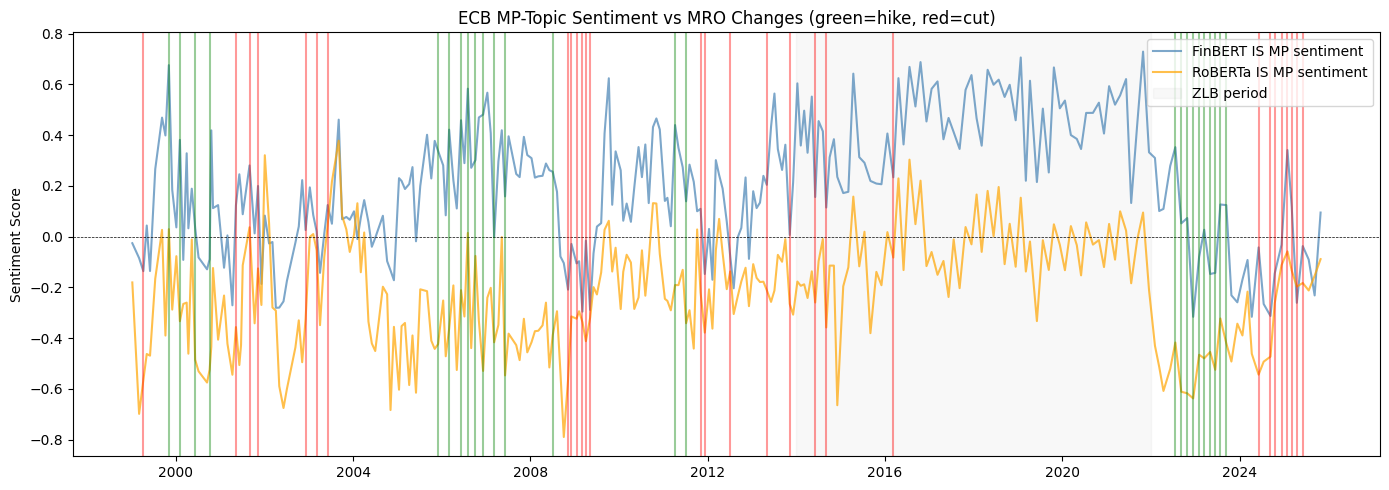

In [139]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Sentiment line
ax1.plot(data_labeled.index, data_labeled['finbert_IS_MP_mean'], 
         color='steelblue', label='FinBERT IS MP sentiment', alpha=0.7)
ax1.plot(data_labeled.index, data_labeled['roberta_IS_MP_mean'], 
         color='orange', label='RoBERTa IS MP sentiment', alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.set_ylabel('Sentiment Score')

# MRO changes as vertical lines
mro_changes = data_labeled[data_labeled['MRO_diff'] != 0]
for date, row in mro_changes.iterrows():
    color = 'red' if row['MRO_diff'] < 0 else 'green'
    ax1.axvline(date, color=color, alpha=0.4, linewidth=1.5)

# ZLB shading
ax1.axvspan(pd.Timestamp('2014-01-01'), pd.Timestamp('2021-12-31'), 
            alpha=0.05, color='gray', label='ZLB period')

ax1.legend(loc='upper right')
ax1.set_title('ECB MP-Topic Sentiment vs MRO Changes (green=hike, red=cut)')
plt.tight_layout()
plt.show()

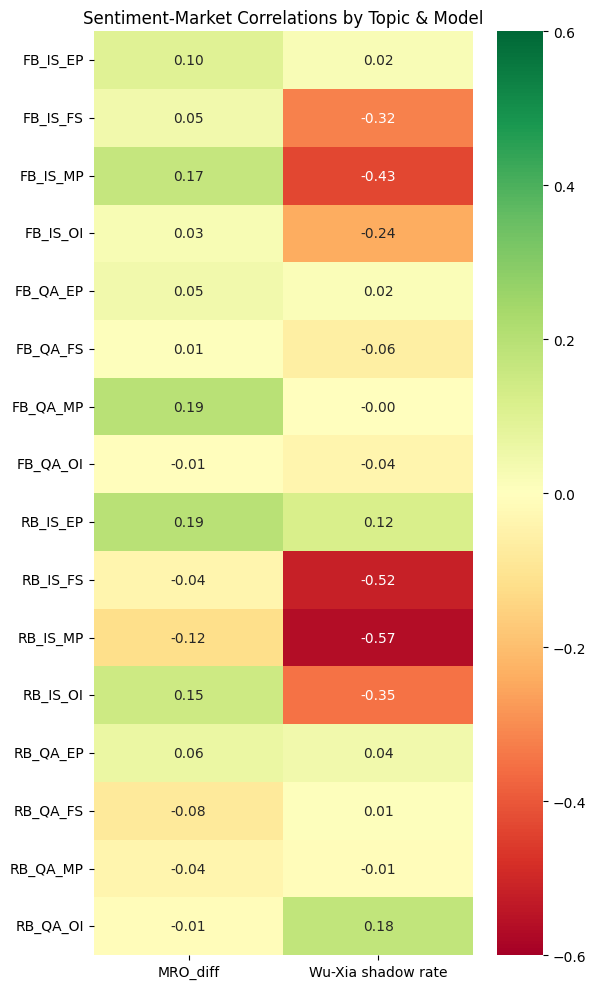

In [140]:
mean_cols = [c for c in data_labeled.columns if c.endswith('_mean') 
             and any(t in c for t in ['_MP_', '_EP_', '_FS_', '_OI_'])]

corr_df = data_labeled[mean_cols + ['MRO_diff', 'Wu-Xia shadow rate']]\
    .corr()[['MRO_diff', 'Wu-Xia shadow rate']]\
    .loc[mean_cols]

# Rename for readability
corr_df.index = [i.replace('finbert_', 'FB_').replace('roberta_', 'RB_')
                   .replace('_mean', '') for i in corr_df.index]

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, vmin=-0.6, vmax=0.6, ax=ax)
ax.set_title('Sentiment-Market Correlations by Topic & Model')
plt.tight_layout()
plt.show()

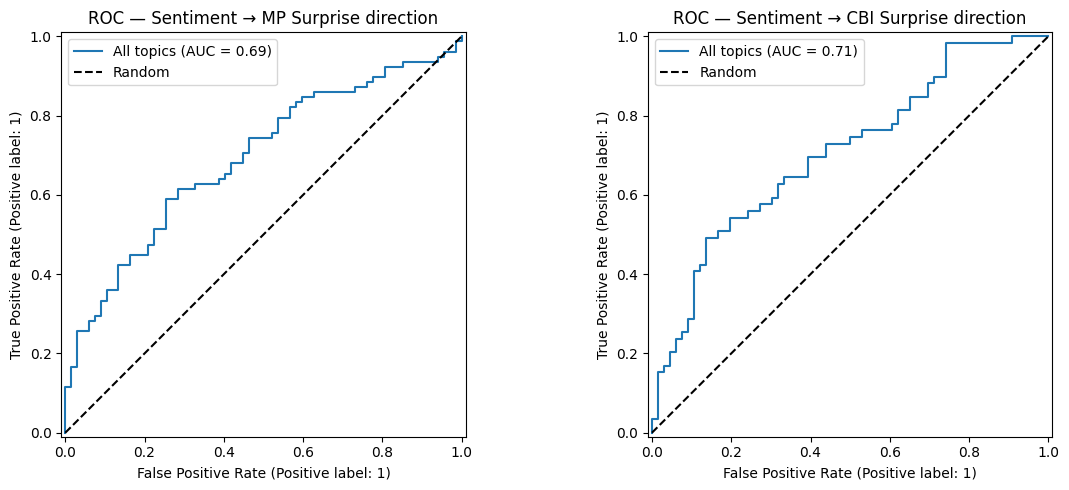

In [141]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (target, label) in zip(axes, [('MP_pm', 'MP Surprise'), ('CBI_pm', 'CBI Surprise')]):
    subset = data_labeled[data_labeled[target] != 0]\
             .dropna(subset=mean_cols + [target])
    X = StandardScaler().fit_transform(subset[mean_cols])
    y = (subset[target] > 0).astype(int)
    
    model = LogisticRegression(max_iter=1000).fit(X, y)
    y_prob = model.predict_proba(X)[:, 1]
    
    RocCurveDisplay.from_predictions(y, y_prob, ax=ax, name='All topics')
    ax.plot([0,1], [0,1], 'k--', label='Random')
    ax.set_title(f'ROC — Sentiment → {label} direction')
    ax.legend()

plt.tight_layout()
plt.show()

In [142]:
for target in ['MP_pm', 'CBI_pm']:
    subset = data_labeled[data_labeled[target] != 0]\
             .dropna(subset=mean_cols + [target])
    X = StandardScaler().fit_transform(subset[mean_cols])
    y = (subset[target] > 0).astype(int)
    model = LogisticRegression(max_iter=1000)
    cv_auc = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()
    print(f"{target} CV AUC: {cv_auc:.3f}")

MP_pm CV AUC: 0.415
CBI_pm CV AUC: 0.369


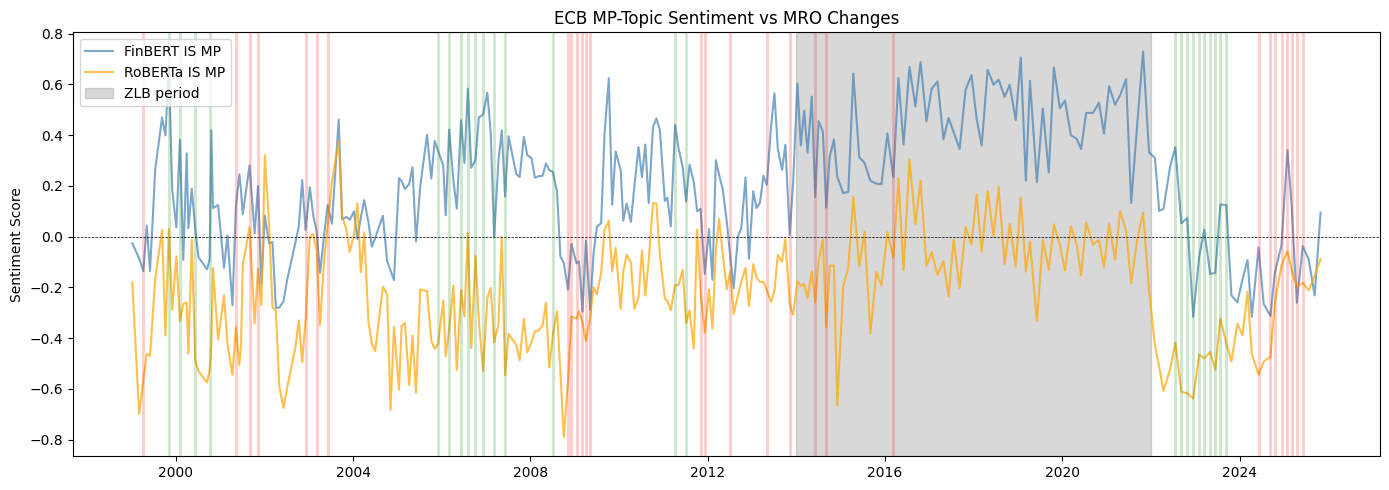

In [143]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(data_labeled.index, data_labeled['finbert_IS_MP_mean'], 
         color='steelblue', label='FinBERT IS MP', alpha=0.7)
ax1.plot(data_labeled.index, data_labeled['roberta_IS_MP_mean'], 
         color='orange', label='RoBERTa IS MP', alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.set_ylabel('Sentiment Score')

# Only mark ACTUAL rate changes, not every meeting
mro_hikes = data_labeled[data_labeled['MRO_diff'] > 0]
mro_cuts = data_labeled[data_labeled['MRO_diff'] < 0]

for date in mro_hikes.index:
    ax1.axvline(date, color='green', alpha=0.2, linewidth=2)
for date in mro_cuts.index:
    ax1.axvline(date, color='red', alpha=0.2, linewidth=2)

ax1.axvspan(pd.Timestamp('2014-01-01'), pd.Timestamp('2021-12-31'), 
            alpha=0.3, color='gray', label='ZLB period')

ax1.legend()
ax1.set_title('ECB MP-Topic Sentiment vs MRO Changes')
plt.tight_layout()
plt.show()

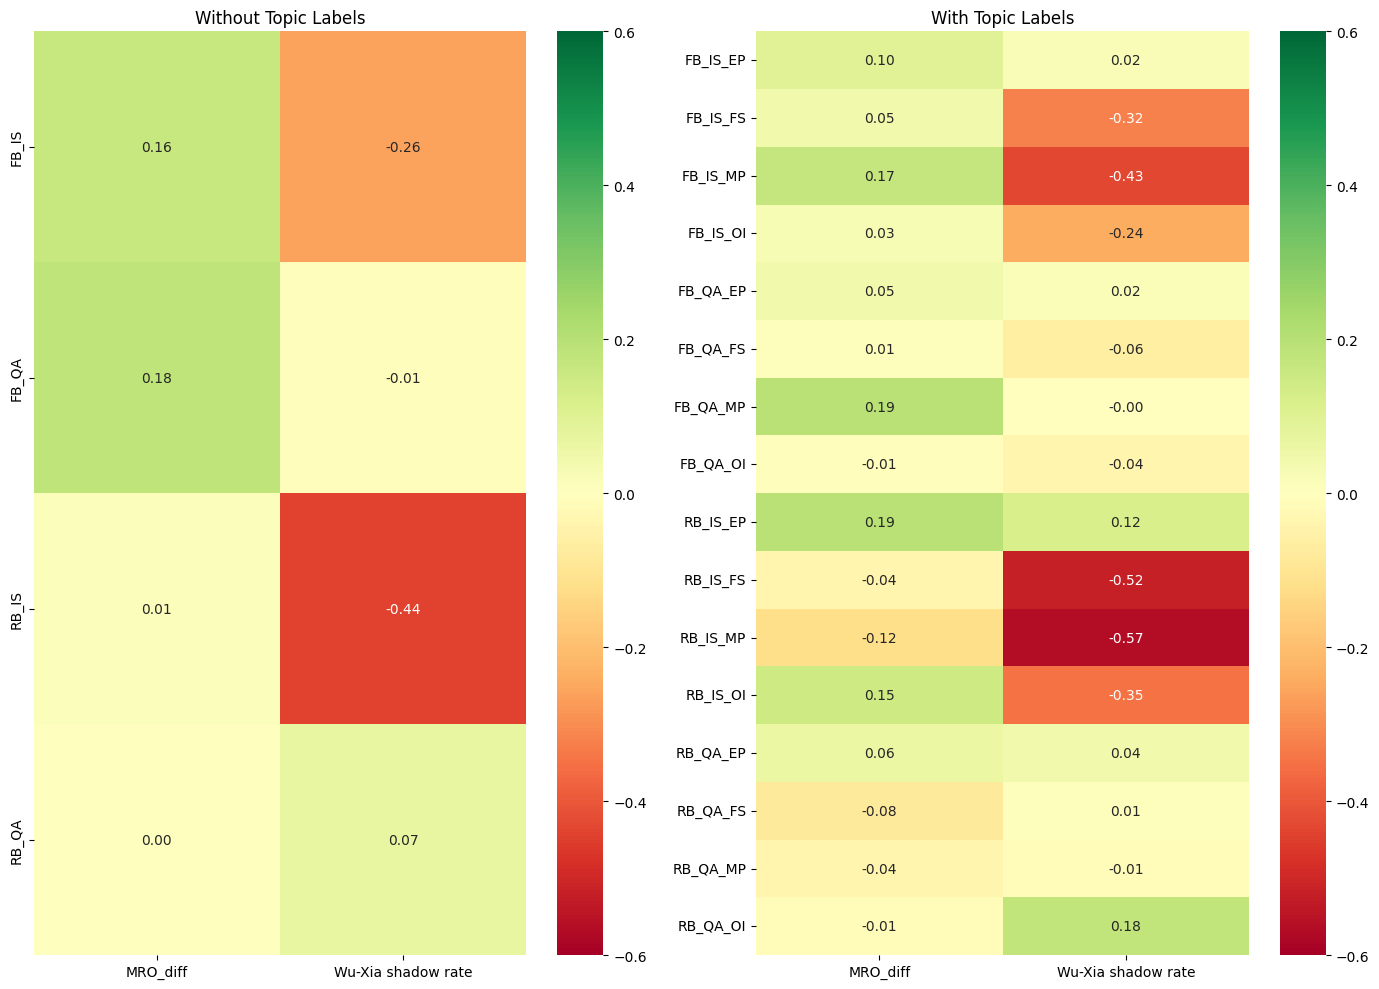

In [144]:
data_nolabel = return_data(with_label=False, market_data="all").set_index("date")
data_nolabel["MRO_diff"] = data_nolabel["MRO announced"] - data_nolabel["MRO"]

no_label_cols = [c for c in data_nolabel.columns if c.endswith('_mean') 
                 and ('finbert' in c or 'roberta' in c)]
label_cols = mean_cols  # already defined

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

for ax, (cols, title) in zip(axes, [
    (no_label_cols, 'Without Topic Labels'),
    (label_cols, 'With Topic Labels')
]):
    corr = data_nolabel[cols + ['MRO_diff', 'Wu-Xia shadow rate']]\
           .corr()[['MRO_diff', 'Wu-Xia shadow rate']].loc[cols] \
           if 'Without' in title else \
           data_labeled[cols + ['MRO_diff', 'Wu-Xia shadow rate']]\
           .corr()[['MRO_diff', 'Wu-Xia shadow rate']].loc[cols]
    
    corr.index = [i.replace('finbert_', 'FB_').replace('roberta_', 'RB_')
                   .replace('_mean', '') for i in corr.index]
    
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-0.6, vmax=0.6, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [145]:
# First-difference the sentiment — change from previous meeting
sentiment_mean_cols = [c for c in data_labeled.columns if c.endswith('_mean')]

data_diff = data_labeled[sentiment_mean_cols].diff()
data_diff.columns = [c + '_diff' for c in sentiment_mean_cols]

# Merge back
data_combined = pd.concat([data_labeled, data_diff], axis=1).dropna()

# Now correlate the CHANGES against market variables
diff_cols = list(data_diff.columns)
corr_diff = data_combined[diff_cols + ['MRO_diff', 'Wu-Xia shadow rate', 'MP_pm', 'CBI_pm']]\
    .corr()[['MRO_diff', 'Wu-Xia shadow rate', 'MP_pm', 'CBI_pm']]\
    .loc[diff_cols]

# Focus on mean cols only
mean_diff_cols = [c for c in diff_cols if 'mean' in c]
print(corr_diff.loc[mean_diff_cols].to_string())

                         MRO_diff  Wu-Xia shadow rate     MP_pm    CBI_pm
finbert_IS_EP_mean_diff -0.086759            0.000364 -0.083104 -0.006765
finbert_IS_FS_mean_diff -0.019907           -0.003446  0.060774  0.146743
finbert_IS_MP_mean_diff  0.112759            0.010954 -0.021714 -0.023134
finbert_IS_OI_mean_diff -0.055811            0.020084  0.067778 -0.007280
finbert_QA_EP_mean_diff -0.034610           -0.014265  0.008295  0.021515
finbert_QA_FS_mean_diff -0.018815           -0.008601 -0.227184 -0.020065
finbert_QA_MP_mean_diff  0.037091           -0.009975  0.010934  0.088646
finbert_QA_OI_mean_diff  0.096901           -0.004819  0.106088 -0.044565
roberta_IS_EP_mean_diff -0.078409           -0.015671 -0.047974 -0.124771
roberta_IS_FS_mean_diff  0.045497           -0.004896  0.049850  0.083824
roberta_IS_MP_mean_diff  0.007145            0.019617  0.061070  0.030038
roberta_IS_OI_mean_diff  0.115102            0.012674  0.003356 -0.027951
roberta_QA_EP_mean_diff -0.083819     

In [146]:
# All mean cols - both labeled and non-labeled
all_mean_cols_labeled = [c for c in data_labeled.columns if c.endswith('_mean')]
all_mean_cols_nolabel = [c for c in data_nolabel.columns if c.endswith('_mean')]
data_nolabel["MRO_diff"] = data_nolabel["MRO announced"] - data_nolabel["MRO"]
data_labeled["MRO_diff"] = data_labeled["MRO announced"] - data_labeled["MRO"]

for dataset, cols, name in [
    (data_labeled, all_mean_cols_labeled, 'With topic labels'),
    (data_nolabel, all_mean_cols_nolabel, 'Without topic labels')
]:
    data_zscore = pd.DataFrame(index=dataset.index)
    for col in cols:
        data_zscore[col + '_diff'] = dataset[col].diff(1)

    data_combined = pd.concat([dataset, data_zscore], axis=1).dropna()
    zscore_cols = [c for c in data_zscore.columns if 'mean' in c]

    corr_z = data_combined[zscore_cols + ['MRO_diff', 'Wu-Xia shadow rate', 'MP_pm', 'CBI_pm']]\
    .corr()[['MRO_diff', 'Wu-Xia shadow rate', 'MP_pm', 'CBI_pm']].loc[zscore_cols]
    
    print(f"\n=== {name} ===")
    print(corr_z.to_string())


=== With topic labels ===
                         MRO_diff  Wu-Xia shadow rate     MP_pm    CBI_pm
finbert_IS_EP_mean_diff -0.086759            0.000364 -0.083104 -0.006765
finbert_IS_FS_mean_diff -0.019907           -0.003446  0.060774  0.146743
finbert_IS_MP_mean_diff  0.112759            0.010954 -0.021714 -0.023134
finbert_IS_OI_mean_diff -0.055811            0.020084  0.067778 -0.007280
finbert_QA_EP_mean_diff -0.034610           -0.014265  0.008295  0.021515
finbert_QA_FS_mean_diff -0.018815           -0.008601 -0.227184 -0.020065
finbert_QA_MP_mean_diff  0.037091           -0.009975  0.010934  0.088646
finbert_QA_OI_mean_diff  0.096901           -0.004819  0.106088 -0.044565
roberta_IS_EP_mean_diff -0.078409           -0.015671 -0.047974 -0.124771
roberta_IS_FS_mean_diff  0.045497           -0.004896  0.049850  0.083824
roberta_IS_MP_mean_diff  0.007145            0.019617  0.061070  0.030038
roberta_IS_OI_mean_diff  0.115102            0.012674  0.003356 -0.027951
roberta_QA_